# LaLonde Dataset: DAG Falsification with DoWhy

This notebook tests whether a proposed causal DAG for the LaLonde dataset is consistent with the observational data. We encode domain knowledge about labor market dynamics as a directed acyclic graph, then use DoWhy's `falsify_graph` to check whether the conditional independencies implied by the graph hold in the data.

The method is based on testing Local Markov Conditions (LMCs) using a permutation-based approach from:
> Eulig, E., Mastakouri, A. A., Blöbaum, P., Hardt, M., & Janzing, D. (2023). Toward Falsifying Causal Graphs Using a Permutation-Based Test. https://arxiv.org/abs/2305.09565

In [2]:
# Add project root to path so we can import the datasets module
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
# NetworkX 3.x compatibility patch for DoWhy 0.12
# DoWhy 0.12 calls nx.d_separated which was moved in networkx 3.x
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dowhy.gcm.falsify import falsify_graph, plot_evaluation_results, plot_local_insights
from datasets import LalondeDataset

In [5]:
# Load LaLonde dataset with observational data
# This combines experimental treated (185) with non-experimental PSID controls (2,490)
ds = LalondeDataset()
data = ds.observational()

# Cast treat from boolean to int for kernel-based independence tests
data["treat"] = data["treat"].astype(int)

treatment_col = "treat"
outcome_col = "re78"
covariate_cols = ["age", "educ", "black", "hisp", "married", "nodegr", "re74", "re75", "u74", "u75"]

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nTreated: {data.treat.sum()}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (2675, 12)

Columns: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 're78', 'u74', 'u75']

Treated: 185

First few rows:


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,1,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,9930.0460,1.0,1.0
1,1,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,3595.8940,1.0,1.0
2,1,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,24909.4500,1.0,1.0
3,1,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,7506.1460,1.0,1.0
4,1,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,289.7899,1.0,1.0


## The Proposed Causal DAG

We encode domain knowledge about labor market dynamics in the LaLonde dataset:

**Exogenous background characteristics** (no parents):
- `age`, `black`, `hisp` — demographics not caused by other variables in the model

**Causal relationships**:
- Demographics → education and marriage
- Demographics + education + marriage → pre-treatment earnings (`re74`, `re75`)
- Earnings persistence: `re74` → `re75`
- Selection into treatment: all pre-treatment variables → `treat` (confounding)
- Outcome: `treat` + pre-treatment variables → `re78`

**Important decision**: We **exclude** `u74`, `u75`, and `nodegr` from this DAG. These variables are deterministic functions of other variables:
- `u74 = 1[re74 == 0]` (unemployment indicator)
- `u75 = 1[re75 == 0]` (unemployment indicator)  
- `nodegr ≈ 1[educ < 12]` (no high school degree)

Deterministic relationships violate the smoothness assumptions underlying kernel-based conditional independence tests, leading to spurious violations. We will test a version including them later to demonstrate this issue.

In [ ]:
# Define the proposed causal DAG
dag = nx.DiGraph()

edges = [
    # Demographics -> education
    ("age", "educ"), ("black", "educ"), ("hisp", "educ"),
    # Demographics -> marriage
    ("age", "married"), ("black", "married"), ("hisp", "married"),
    # Demographics + education + marriage -> 1974 earnings
    ("age", "re74"), ("black", "re74"), ("hisp", "re74"),
    ("educ", "re74"), ("married", "re74"),
    # 1974 earnings + demographics -> 1975 earnings (earnings persistence)
    ("re74", "re75"), ("age", "re75"), ("black", "re75"), ("hisp", "re75"),
    ("educ", "re75"), ("married", "re75"),
    # All pre-treatment -> treatment selection (confounding)
    ("age", "treat"), ("educ", "treat"), ("black", "treat"), ("hisp", "treat"),
    ("married", "treat"), ("re74", "treat"), ("re75", "treat"),
    # Treatment + pre-treatment -> outcome
    ("treat", "re78"), ("age", "re78"), ("educ", "re78"), ("black", "re78"),
    ("hisp", "re78"), ("married", "re78"), ("re74", "re78"), ("re75", "re78"),
]
dag.add_edges_from(edges)

print(f"Nodes: {dag.number_of_nodes()}")
print(f"Edges: {dag.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(dag)}")
print(f"\nNodes: {sorted(dag.nodes())}")

Nodes: 9
Edges: 32
Is DAG: True

Nodes: ['age', 'black', 'educ', 'hisp', 'married', 're74', 're75', 're78', 'treat']


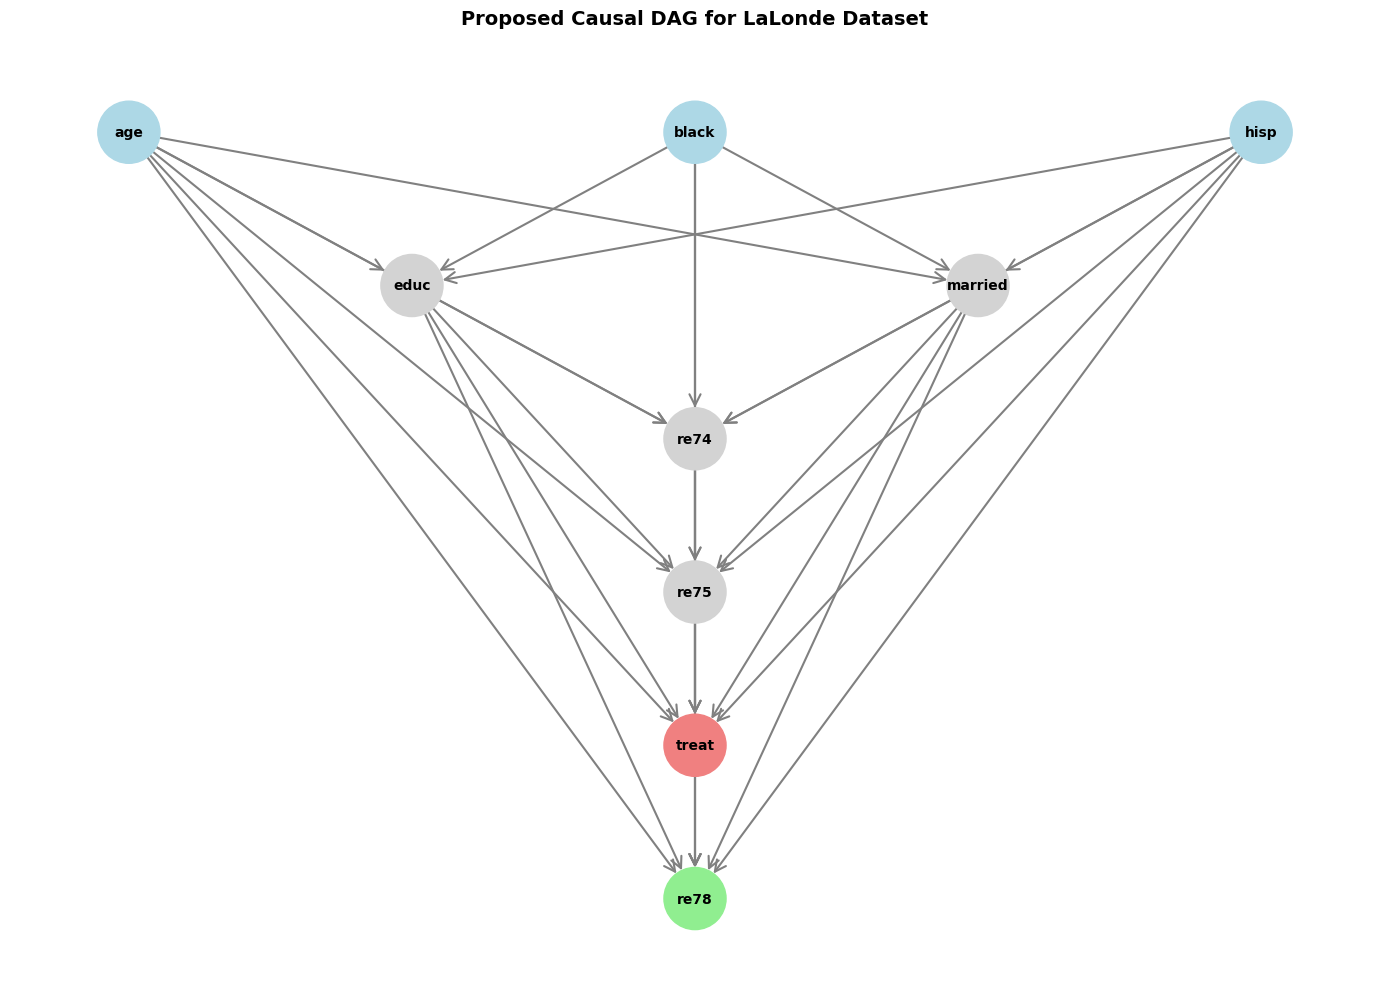

In [7]:
# Visualize the DAG with a custom layered layout
fig, ax = plt.subplots(figsize=(14, 10))

# Define positions in layers (temporal/causal flow from top to bottom)
pos = {
    # Layer 0: Exogenous demographics
    "age": (0, 5),
    "black": (1, 5),
    "hisp": (2, 5),
    # Layer 1: Education and marriage
    "educ": (0.5, 4),
    "married": (1.5, 4),
    # Layer 2: 1974 earnings
    "re74": (1, 3),
    # Layer 3: 1975 earnings
    "re75": (1, 2),
    # Layer 4: Treatment
    "treat": (1, 1),
    # Layer 5: Outcome
    "re78": (1, 0),
}

# Color nodes by type
node_colors = []
for node in dag.nodes():
    if node in ["age", "black", "hisp"]:
        node_colors.append("lightblue")  # Exogenous
    elif node == "treat":
        node_colors.append("lightcoral")  # Treatment
    elif node == "re78":
        node_colors.append("lightgreen")  # Outcome
    else:
        node_colors.append("lightgray")  # Intermediate variables

nx.draw_networkx(
    dag,
    pos=pos,
    node_color=node_colors,
    node_size=2000,
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
    arrowstyle="->",
    edge_color="gray",
    width=1.5,
    ax=ax,
)

ax.set_title("Proposed Causal DAG for LaLonde Dataset", fontsize=14, fontweight="bold", pad=20)
ax.axis("off")
plt.tight_layout()
plt.show()

## Falsification Test

The `falsify_graph` function tests whether the proposed DAG is consistent with the data by checking **Local Markov Conditions (LMCs)**:

> For each node X with parents Pa_X, X should be conditionally independent of all its non-descendants given Pa_X.

The test works as follows:
1. Count LMC violations in the given DAG using kernel-based conditional independence tests
2. Generate random node-permuted DAGs and count their LMC violations
3. Compare: if the given DAG has significantly fewer violations than random DAGs, it is **not falsified**

The result has two key attributes:
- **`falsifiable`**: The DAG makes testable predictions (lies in a different Markov Equivalence Class than most permuted DAGs)
- **`falsified`**: The DAG is falsifiable AND has more violations than expected by chance

**Note**: This test can take several minutes due to kernel-based conditional independence tests on 2,675 observations.

In [8]:
# Run falsification test on the proposed DAG
dag_columns = list(dag.nodes)
dag_data = data[dag_columns]

print("Running falsification test (this may take a few minutes)...\n")

result = falsify_graph(
    dag,
    dag_data,
    show_progress_bar=True,
)

print(result)

Running falsification test (this may take a few minutes)...



Test permutations of given graph: 100%|██████████| 20/20 [03:18<00:00,  9.93s/it]

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/8 LMCs and is better than 40.0% of the permuted DAGs (p-value: 0.60).        |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we reject the DAG.                                                                                    |
+-------------------------------------------------------------------------------------------------------+


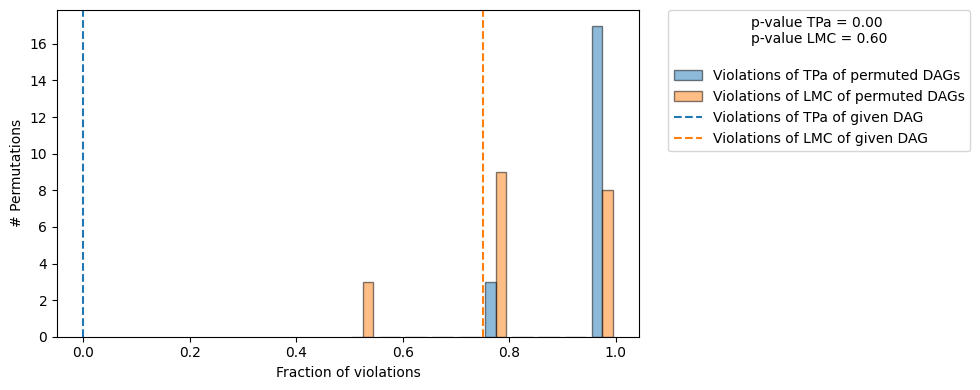

In [9]:
# Visualize the distribution of LMC violations
plot_evaluation_results(result, figsize=(10, 4))

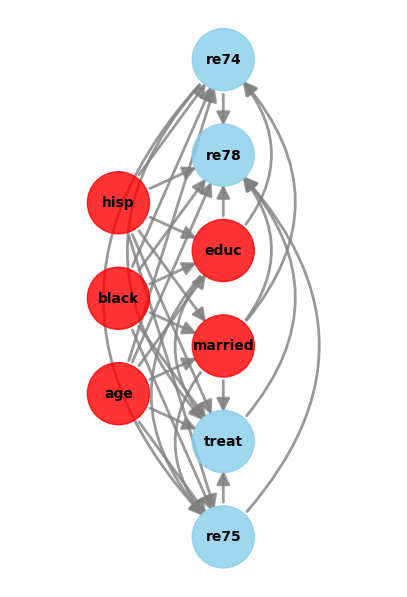

In [10]:
# Plot which nodes have LMC violations (if any)
plot_local_insights(dag, result)

## Interpretation

The falsification result tells us whether the data contradicts our proposed causal structure:

- **Not falsified**: The conditional independencies implied by the DAG hold in the data. This does NOT prove the DAG is correct—only that the data is consistent with it. Many other DAGs might also be consistent.

- **Falsified**: The DAG makes predictions that are violated by the data, suggesting the causal structure is incorrect.

- **Not falsifiable**: The DAG doesn't make enough testable predictions (most permuted DAGs are in the same Markov Equivalence Class), so the test lacks power.

The p-value represents the fraction of random DAGs with equal or more LMC violations than our proposed DAG. A low p-value (< 0.05) means our DAG performs significantly better than random, supporting (but not proving) the hypothesized causal structure.

## Testing a Wrong DAG

As a negative control, we construct a DAG that encodes an **incorrect** causal story to verify that the falsification test can catch obvious mistakes.

We'll test a DAG where:
- The outcome (`re78`) causes treatment assignment: `re78 → treat` (backwards!)
- We remove most confounding edges (demographics and earnings no longer cause treatment)

This represents a scenario where someone incorrectly believes that future earnings determine treatment rather than the other way around. The falsification test should detect this error.

In [ ]:
# Define a deliberately wrong DAG
wrong_dag = nx.DiGraph()

wrong_edges = [
    # Keep the covariate structure the same
    ("age", "educ"), ("black", "educ"), ("hisp", "educ"),
    ("age", "married"), ("black", "married"), ("hisp", "married"),
    ("age", "re74"), ("black", "re74"), ("hisp", "re74"),
    ("educ", "re74"), ("married", "re74"),
    ("re74", "re75"), ("age", "re75"), ("black", "re75"), ("hisp", "re75"),
    ("educ", "re75"), ("married", "re75"),
    # WRONG: outcome causes treatment (reversed arrow)
    ("re78", "treat"),
    # Outcome still depends on covariates
    ("age", "re78"), ("educ", "re78"), ("black", "re78"),
    ("hisp", "re78"), ("married", "re78"), ("re74", "re78"), ("re75", "re78"),
]
wrong_dag.add_edges_from(wrong_edges)

print(f"Wrong DAG - Nodes: {wrong_dag.number_of_nodes()}, Edges: {wrong_dag.number_of_edges()}")
print("\nRunning falsification test on wrong DAG...\n")

wrong_result = falsify_graph(
    wrong_dag,
    dag_data,
    show_progress_bar=False,
)

print(wrong_result)

In [ ]:
# Visualize the wrong DAG's performance
plot_evaluation_results(wrong_result, figsize=(10, 4), title="Wrong DAG: re78 → treat")

## Effect of Deterministic Variables

Earlier we excluded `u74`, `u75`, and `nodegr` from the DAG. These variables have **deterministic relationships** with other variables:

- `u74 = 1` if and only if `re74 == 0` (exact deterministic function)
- `u75 = 1` if and only if `re75 == 0` (exact deterministic function)
- `nodegr = 1` if and only if `educ < 12` (deterministic threshold)

When we condition on `re74` in a conditional independence test, `u74` becomes a constant (has zero variance), making the test degenerate. Kernel-based conditional independence tests assume smooth continuous distributions and struggle with such point masses.

Let's test the full DAG including these variables to demonstrate the issue.

In [ ]:
# Define full DAG with deterministic variables
full_dag = dag.copy()
full_dag.add_edges_from([
    ("educ", "nodegr"),
    ("re74", "u74"),
    ("re75", "u75"),
    ("nodegr", "treat"),
    ("u74", "treat"),
    ("u75", "treat"),
])

full_dag_columns = list(full_dag.nodes)
full_dag_data = data[full_dag_columns]

print(f"Full DAG - Nodes: {full_dag.number_of_nodes()}, Edges: {full_dag.number_of_edges()}")
print("\nRunning falsification test on full DAG with deterministic variables...")
print("(This may take longer due to more LMC tests)\n")

full_result = falsify_graph(
    full_dag,
    full_dag_data,
    show_progress_bar=False,
    n_permutations=20,  # Use fewer permutations due to longer runtime
)

print(full_result)

In [ ]:
# Visualize the full DAG's performance
plot_evaluation_results(full_result, figsize=(10, 4), title="Full DAG with Deterministic Variables")

## Summary

This notebook tested whether our proposed causal DAG for the LaLonde dataset is consistent with observational data:

1. **Proposed DAG** (without deterministic variables): We encoded domain knowledge about labor market dynamics—demographics cause education and earnings, which confound treatment selection, which affects outcomes. The falsification test evaluates whether this structure is consistent with the data.

2. **Wrong DAG** (reversed causation): A deliberately incorrect DAG with `re78 → treat` should be caught by the falsification test, demonstrating the method's ability to detect structural errors.

3. **Deterministic variables**: Including `u74`, `u75`, and `nodegr` introduces spurious violations because kernel-based independence tests cannot handle deterministic relationships. This highlights the importance of careful variable selection for graph falsification.

4. **Interpretation**: Graph falsification is a **necessary but not sufficient** test of a causal model. Passing the test means the data doesn't contradict the graph, not that the graph is uniquely correct. Other DAGs in the same Markov Equivalence Class would also pass.

### Connection to Previous Notebooks

While notebooks 01-03 estimated treatment effects using matching and metalearners, this notebook tests the **structural assumptions** that underlie those estimates. The confounding relationships encoded in this DAG (demographics and earnings → treatment) are exactly what methods like propensity score matching and doubly robust estimation attempt to control for.